In [6]:
# =======================
# Imports
# =======================
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import joblib
import random
import numpy as np
from statistics import mean, stdev
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
import config

# --------------------------
# Set seeds for reproducibility
# --------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
g = torch.Generator()
g.manual_seed(SEED)


# --------------------------
# Hyperparameters: (for my own reference)
# --------------------------
# lr (learning rate)
# batch size 32
# hidden_dim
# number_of_epochs 
# patience

# =======================
# Custom Dataset
# =======================
class MultimodalDataset(Dataset):
    def __init__(self, clin_path, mrna_path, mut_path, labels_path):
        # Load preprocessed data
        self.clinical = joblib.load(clin_path).to_numpy().astype(float)
        self.mrna = joblib.load(mrna_path).to_numpy().astype(float)
        self.mutation = joblib.load(mut_path).to_numpy().astype(float)
        self.labels = joblib.load(labels_path).to_numpy().astype(float)
        print(self.clinical.shape)
        print(self.mrna.shape)
        print(self.mutation.shape)
                
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.clinical[idx], dtype=torch.float32),
            torch.tensor(self.mrna[idx], dtype=torch.float32),
            torch.tensor(self.mutation[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

# =======================
# Paths
# =======================
base_dir = "../preprocessed_data/stability_selection"

train_dataset = MultimodalDataset(
    f"{base_dir}/train/clinical.pkl",
    f"{base_dir}/train/mrna.pkl",
    f"{base_dir}/train/mutation.pkl",
    f"{base_dir}/train/labels.pkl"
)
# FIXME TESTING CHANGED VAL AND TEST
val_dataset = MultimodalDataset(
    f"{base_dir}/val/clinical.pkl",
    f"{base_dir}/val/mrna.pkl",
    f"{base_dir}/val/mutation.pkl",
    f"{base_dir}/val/labels.pkl"
)

train_loader = DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, generator=g, worker_init_fn=lambda _: np.random.seed(SEED)
)
val_loader = DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE, generator=g, worker_init_fn=lambda _: np.random.seed(SEED)
)

# =======================
# Simple Neural Network
# =======================
class SimpleMultimodalNet(nn.Module):
    def __init__(self, clin_dim, mrna_dim, mut_dim, hidden_dim=config.HIDDEN_DIM, dropout=config.DROPOUT):
        super().__init__()

        # Separate encoders for each modality
        self.clinical_fc = nn.Sequential(
            nn.Linear(clin_dim, hidden_dim), 
            nn.ReLU(),
            nn.Dropout(dropout)
            )
        self.mrna_fc = nn.Sequential(
            nn.Linear(mrna_dim, hidden_dim), 
            nn.ReLU(),
            nn.Dropout(dropout)
            )
        self.mut_fc = nn.Sequential(
            nn.Linear(mut_dim, hidden_dim), 
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Fusion layer
        self.fusion_fc = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),  # Binary output
        )
        
    def forward(self, clin, mrna, mut):
        clin_emb = self.clinical_fc(clin)
        mrna_emb = self.mrna_fc(mrna)
        mut_emb = self.mut_fc(mut)
        
        # Concatenate embeddings
        fused = torch.cat([clin_emb, mrna_emb, mut_emb], dim=1)
        output = self.fusion_fc(fused)
        return output.squeeze()


# =======================
# Initialize Model
# =======================
# Use one batch to get dimensions
sample_batch = next(iter(train_loader))
clin_dim = sample_batch[0].shape[1]
mrna_dim = sample_batch[1].shape[1]
mut_dim = sample_batch[2].shape[1]
model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim)

# =======================
# Loss and Optimizer
# =======================
# Compute pos_weight
num_pos = (train_dataset.labels == 1).sum()
num_neg = (train_dataset.labels == 0).sum()
pos_weight_val = num_neg / num_pos

# Convert to tensor and move to the same device as model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor(pos_weight_val, dtype=torch.float32, device=device)

# Initialize loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --------------------------
# Training loop with validation metrics
# --------------------------
best_auroc = 0
counter = 0

for epoch in range(config.NUM_EPOCHS):
    model.train()
    train_losses = []

    for clin, mrna, mut, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(clin, mrna, mut)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    avg_train_loss = sum(train_losses) / len(train_losses)

    # --- Validation ---
    model.eval()
    val_losses = []
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for clin, mrna, mut, labels in val_loader:
            outputs = model(clin, mrna, mut)
            val_loss = criterion(outputs, labels)
            val_losses.append(val_loss.item())
            
            all_labels.append(labels)
            all_preds.append(torch.sigmoid(outputs))

    avg_val_loss = sum(val_losses) / len(val_losses)
    all_labels = torch.cat(all_labels)
    all_preds = torch.cat(all_preds)

    # Binarize predictions at 0.5 threshold
    pred_labels = (all_preds >= 0.5).float()

    val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())
    val_precision = precision_score(all_labels.numpy(), pred_labels.numpy(), zero_division=0)
    val_recall = recall_score(all_labels.numpy(), pred_labels.numpy(), zero_division=0)
    val_f1 = f1_score(all_labels.numpy(), pred_labels.numpy(), zero_division=0)

    print(f"Epoch {epoch+1} - "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, "
          f"AUROC: {val_auroc:.4f}, "
          f"Precision: {val_precision:.4f}, "
          f"Recall: {val_recall:.4f}, "
          f"F1: {val_f1:.4f}")

    # --- Early stopping based on AUROC ---
    if val_auroc >= best_auroc:
        best_auroc = val_auroc
        counter = 0
        # Optionally save best model
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= config.PATIENCE:
            print(f"Early stopping at epoch {epoch+1} with patience of {config.PATIENCE}")
            break



(316, 31)
(316, 2195)
(316, 17650)
(68, 31)
(68, 2195)
(68, 17650)
Epoch 1 - Train Loss: 28.5699, Val Loss: 22.6922, AUROC: 0.5000, Precision: 0.1912, Recall: 1.0000, F1: 0.3210
Epoch 2 - Train Loss: 13.8905, Val Loss: 17.6494, AUROC: 0.4042, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 3 - Train Loss: 7.7570, Val Loss: 1.1221, AUROC: 0.7804, Precision: 0.3750, Recall: 0.2308, F1: 0.2857
Epoch 4 - Train Loss: 3.7078, Val Loss: 1.2535, AUROC: 0.7888, Precision: 0.2097, Recall: 1.0000, F1: 0.3467
Epoch 5 - Train Loss: 1.9368, Val Loss: 2.1109, AUROC: 0.7636, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 6 - Train Loss: 1.2481, Val Loss: 1.6167, AUROC: 0.8126, Precision: 0.2000, Recall: 1.0000, F1: 0.3333
Epoch 7 - Train Loss: 1.2625, Val Loss: 1.7279, AUROC: 0.7748, Precision: 0.3333, Recall: 0.0769, F1: 0.1250
Epoch 8 - Train Loss: 1.0588, Val Loss: 1.2602, AUROC: 0.7790, Precision: 0.2364, Recall: 1.0000, F1: 0.3824
Epoch 9 - Train Loss: 0.8626, Val Loss: 1.8396, AUROC: 0.

In [12]:
def run_multiple_seeds_with_test(train_loader, val_loader, test_loader, num_runs=5):
    val_aurocs = []
    test_aurocs = []
    
    for i in range(num_runs):
        seed = 42 + i
        print(f"\n==========================")
        print(f" Run {i+1}/{num_runs} with SEED={seed}")
        print(f"==========================")
        
        # --- Set seeds for reproducibility ---
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        
        # --- Reinitialize model, loss, optimizer ---
        model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        
        best_auroc = 0
        best_model_state = None
        counter = 0
        
        # --- Training loop ---
        for epoch in range(config.NUM_EPOCHS):
            model.train()
            for clin, mrna, mut, labels in train_loader:
                clin, mrna, mut, labels = clin.to(device), mrna.to(device), mut.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(clin, mrna, mut)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            
            # --- Validation phase ---
            model.eval()
            all_labels, all_preds = [], []
            with torch.no_grad():
                for clin, mrna, mut, labels in val_loader:
                    clin, mrna, mut, labels = clin.to(device), mrna.to(device), mut.to(device), labels.to(device)
                    outputs = model(clin, mrna, mut)
                    all_labels.append(labels.cpu())
                    all_preds.append(torch.sigmoid(outputs).cpu())
            
            all_labels = torch.cat(all_labels)
            all_preds = torch.cat(all_preds)
            val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())
            
            if val_auroc > best_auroc:
                best_auroc = val_auroc
                best_model_state = model.state_dict()
                counter = 0
            else:
                counter += 1
                if counter >= config.PATIENCE:
                    break
        
        print(f"Best Validation AUROC for SEED {seed}: {best_auroc:.4f}")
        val_aurocs.append(best_auroc)
        
        # --- Evaluate best model on test set ---
        model.load_state_dict(best_model_state)
        model.eval()
        all_labels, all_preds = [], []
        with torch.no_grad():
            for clin, mrna, mut, labels in test_loader:
                clin, mrna, mut, labels = clin.to(device), mrna.to(device), mut.to(device), labels.to(device)
                outputs = model(clin, mrna, mut)
                all_labels.append(labels.cpu())
                all_preds.append(torch.sigmoid(outputs).cpu())
        
        all_labels = torch.cat(all_labels)
        all_preds = torch.cat(all_preds)
        test_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())
        
        print(f"Test AUROC for SEED {seed}: {test_auroc:.4f}")
        test_aurocs.append(test_auroc)
    
    # --- Summary ---
    print("\n==========================")
    print(" Summary across runs ")
    print("==========================")
    print(f"Validation AUROC: Mean={mean(val_aurocs):.4f}, Std={stdev(val_aurocs):.4f}")
    print(f"Test AUROC      : Mean={mean(test_aurocs):.4f}, Std={stdev(test_aurocs):.4f}")
    print(f"All Validation Runs: {[round(a, 4) for a in val_aurocs]}")
    print(f"All Test Runs       : {[round(a, 4) for a in test_aurocs]}")

run_multiple_seeds_with_test(train_loader, val_loader, test_loader, num_runs=5)


 Run 1/5 with SEED=42
Best Validation AUROC for SEED 42: 0.8126
Test AUROC for SEED 42: 0.7083

 Run 2/5 with SEED=43
Best Validation AUROC for SEED 43: 0.7972
Test AUROC for SEED 43: 0.7664

 Run 3/5 with SEED=44
Best Validation AUROC for SEED 44: 0.7720
Test AUROC for SEED 44: 0.7411

 Run 4/5 with SEED=45
Best Validation AUROC for SEED 45: 0.7720
Test AUROC for SEED 45: 0.7173

 Run 5/5 with SEED=46
Best Validation AUROC for SEED 46: 0.7455
Test AUROC for SEED 46: 0.7485

 Summary across runs 
Validation AUROC: Mean=0.7799, Std=0.0259
Test AUROC      : Mean=0.7363, Std=0.0236
All Validation Runs: [0.8126, 0.7972, 0.772, 0.772, 0.7455]
All Test Runs       : [0.7083, 0.7664, 0.7411, 0.7173, 0.7485]


In [8]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for clin, mrna, mut, labels in val_loader:
        outputs = model(clin, mrna, mut)
        probs = torch.sigmoid(outputs)
        
        all_labels.append(labels)
        all_probs.append(probs)

# Concatenate batches
all_labels = torch.cat(all_labels).cpu().numpy()
all_probs = torch.cat(all_probs).cpu().numpy()

# --- Find optimal threshold based on F1 score ---
thresholds = np.linspace(0, 1, 101)  # 0.00, 0.01, ..., 1.00
f1_scores = []

for t in thresholds:
    preds = (all_probs >= t).astype(float)
    f1 = f1_score(all_labels, preds)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold for F1: {best_threshold:.2f}, F1 score: {f1_scores[best_idx]:.4f}")

# Use optimal threshold for predictions
preds = (all_probs >= best_threshold).astype(float)

# Metrics
val_loss = criterion(torch.tensor(all_probs), torch.tensor(all_labels)).item()
precision = precision_score(all_labels, preds)
recall = recall_score(all_labels, preds)
auroc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, preds)

# Unpack confusion matrix
tn, fp, fn, tp = cm.ravel()

print(f"Validation Loss: {val_loss:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUROC: {auroc:.4f}")
print("Confusion Matrix:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

Optimal threshold for F1: 0.89, F1 score: 0.5789
Validation Loss: 1.2353
Precision: 0.4400
Recall: 0.8462
AUROC: 0.8126
Confusion Matrix:
True Negatives: 41
False Positives: 14
False Negatives: 2
True Positives: 11


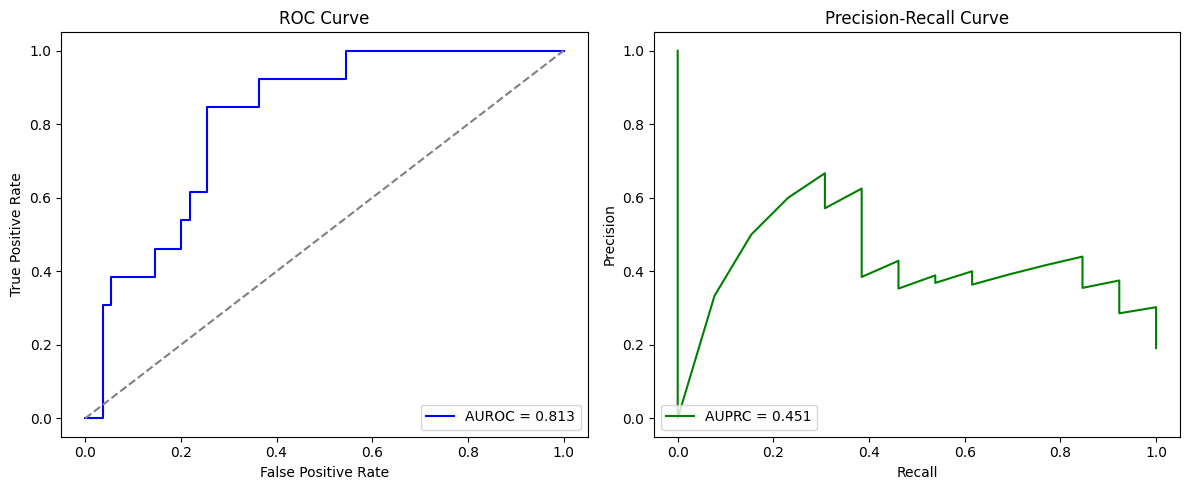

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def plot_metrics(y_true, y_scores):
    y_true = y_true.numpy()
    y_scores = y_scores.numpy()
    
    # ---------- AUROC ----------
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(12,5))
    
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', label=f'AUROC = {roc_auc:.3f}')
    plt.plot([0,1], [0,1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    
    # ----------  AUPRC ----------
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    ap_score = average_precision_score(y_true, y_scores)
    
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', label=f'AUPRC = {ap_score:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    
    plt.tight_layout()
    plt.show()

model.eval()
all_labels = []
all_outputs = []
with torch.no_grad():
    for clin, mrna, mut, labels in val_loader:
        outputs = model(clin, mrna, mut)
        all_outputs.append(torch.sigmoid(outputs))
        all_labels.append(labels)

all_labels = torch.cat(all_labels)
all_outputs = torch.cat(all_outputs)

plot_metrics(all_labels, all_outputs)

In [10]:
test_dataset = MultimodalDataset(
    f"{base_dir}/test/clinical.pkl",
    f"{base_dir}/test/mrna.pkl",
    f"{base_dir}/test/mutation.pkl",
    f"{base_dir}/test/labels.pkl"
)

test_loader = DataLoader(test_dataset, batch_size=32)



model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for clin, mrna, mut, labels in test_loader:
        outputs = model(clin, mrna, mut)
        probs = torch.sigmoid(outputs)
        
        all_labels.append(labels)
        all_probs.append(probs)

# Concatenate batches
all_labels = torch.cat(all_labels).cpu().numpy()
all_probs = torch.cat(all_probs).cpu().numpy()

# --- Find optimal threshold based on F1 score ---
thresholds = np.linspace(0, 1, 101)  # 0.00, 0.01, ..., 1.00
f1_scores = []

for t in thresholds:
    preds = (all_probs >= t).astype(float)
    f1 = f1_score(all_labels, preds)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold for F1: {best_threshold:.2f}, F1 score: {f1_scores[best_idx]:.4f}")

# Use optimal threshold for predictions
preds = (all_probs >= best_threshold).astype(float)

# Metrics
test_loss = criterion(torch.tensor(all_probs), torch.tensor(all_labels)).item()
precision = precision_score(all_labels, preds)
recall = recall_score(all_labels, preds)
auroc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, preds)

# Unpack confusion matrix
tn, fp, fn, tp = cm.ravel()

print(f"Test Loss: {test_loss:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUROC: {auroc:.4f}")
print("Confusion Matrix:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

(68, 31)
(68, 2195)
(68, 17650)
Optimal threshold for F1: 0.86, F1 score: 0.4545
Test Loss: 1.2465
Precision: 0.3125
Recall: 0.8333
AUROC: 0.6562
Confusion Matrix:
True Negatives: 34
False Positives: 22
False Negatives: 2
True Positives: 10


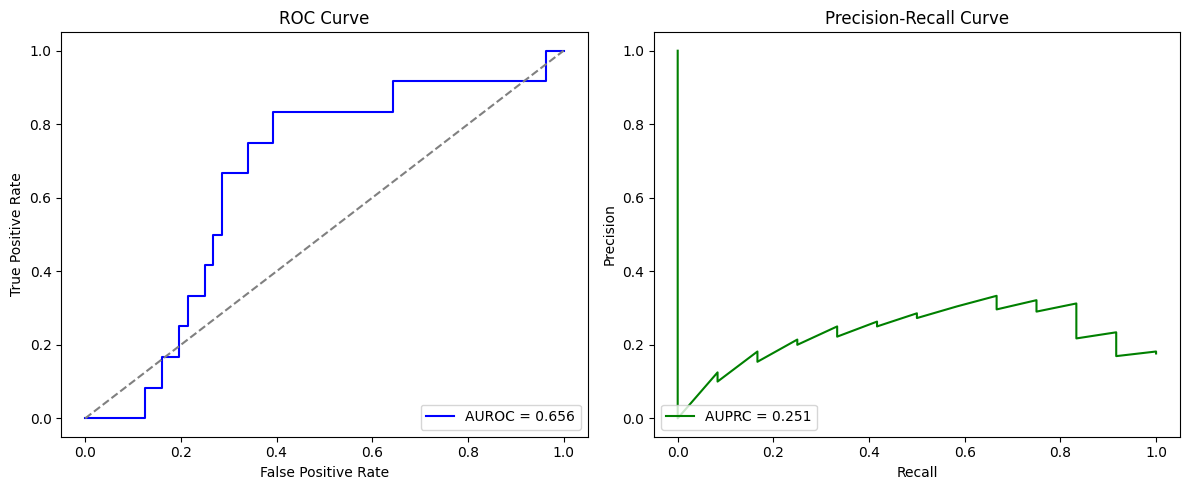

In [11]:
model.eval()
all_labels = []
all_outputs = []
with torch.no_grad():
    for clin, mrna, mut, labels in test_loader:
        outputs = model(clin, mrna, mut)
        all_outputs.append(torch.sigmoid(outputs))
        all_labels.append(labels)

all_labels = torch.cat(all_labels)
all_outputs = torch.cat(all_outputs)

plot_metrics(all_labels, all_outputs)